In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
from tqdm import tqdm
import h5py
import pandas as pd

from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import romb

import astropy.units as u

from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.redshift_utils import *
from darksirenpop.utilities.qlf_utils import log10_QLF_kulkarni, L2M, get_n_of_z, numdens2pdf, pdf2numdens
from darksirenpop.utilities.utils import *

make_nice_plots()

COLORS = ['orangered', 'navy', 'teal', 'goldenrod', 'hotpink', 'indigo', 'crimson']


In [2]:
# Define globals

PLOT_DIR = '/home/lucas/Documents/PhD/darksirenpop/plots'
AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'  # Path to directory where all EM-related files are stored
QUAIA_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'

VERBOSE = True
AGN_ZCUT = 3.0  # Redshift cut of the AGN catalogue
AGN_ZMAX = 10.  # Maximum true redshift of AGN
ZMIN = 1e-6  # Minimum true redshift of GW (not zero because of astropy.cosmology())
ZMAX = 10  # Maximum true redshift of GW
REDSHIFT = np.linspace(ZMIN, ZMAX, 1024+1)  # For plotting
Z_INTEGRAL_AX = np.linspace(ZMIN, ZMAX, int(1024)+1)  # Sets the resolution of the AGN redshift posterior, should be narrow enough to capture all information, see Gray et al. 2022, 2023
LOG10_LBOL_THRESHES = np.array([44.5, 45.5, 46.5])  # Bolometric luminosity thresholds


In [3]:
# Dealing with Kulkarni QLF for z > 3.5

def remove_peak(pdf, z, zstart=3, zstop=3.5):
    '''
    Stitch an exponential decay to the PDF starting at z=3.5.
    We match the value and slope of the pdf at z=3.5.
    '''

    selec = (z > zstart) & (z < zstop)
    z_fit = z[selec]
    pdf_fit = pdf[selec]

    y0 = np.interp(zstop, z, pdf)  # Value of pdf at zstop

    def anchored_exp(x, b):
        return y0 * np.exp(b * (x - zstop))

    param, _ = curve_fit(anchored_exp, z_fit, pdf_fit, p0=[-1])

    corrected_pdf = pdf.copy()
    selec2 = (z >= zstop)
    corrected_pdf[selec2] = anchored_exp(z[selec2], *param)
    corrected_pdf /= romb(corrected_pdf, dx=np.diff(z)[0])
    return corrected_pdf, param


# Generate AGN redshift priors: $\pi_{\rm agn}(z)$

kulkarni...


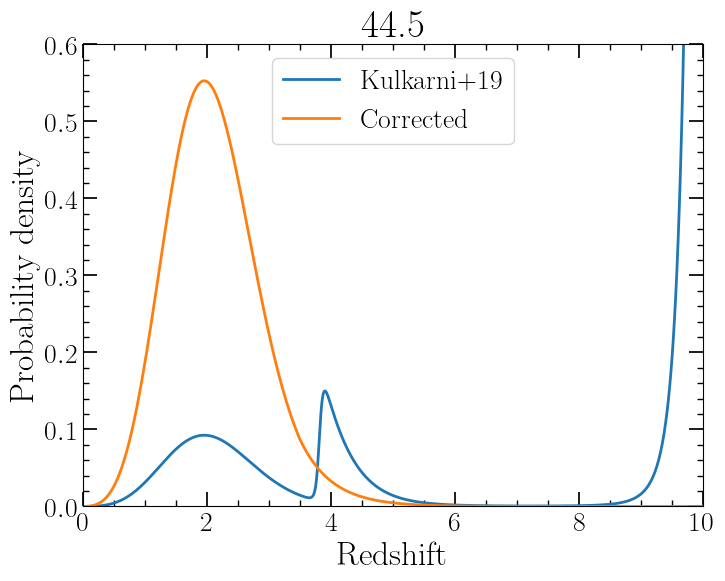

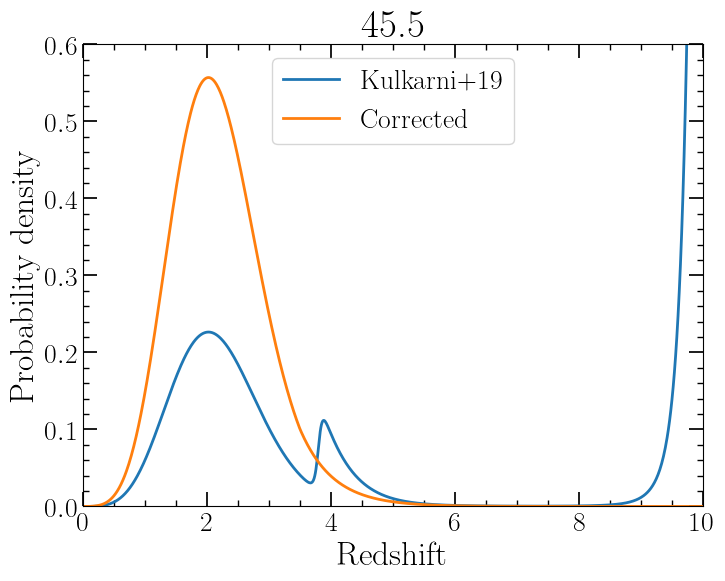

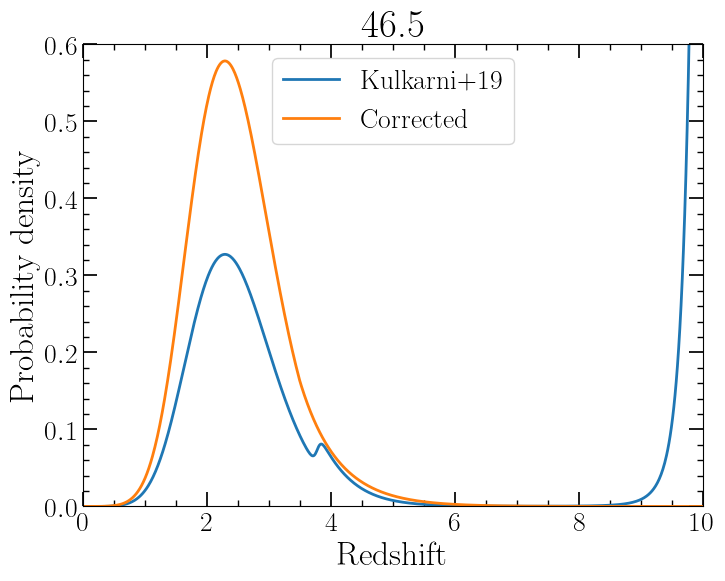

In [4]:
for qlf in ['kulkarni']:  # , 'shenA', 'shenB' not used in Pouw+26
    print(f'{qlf}...')
    for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):
        n_of_z = get_n_of_z(qlf=qlf, log10_Lbol_thresh=L_thresh)  # Step 1: Get number densities by integrating QLF over magnitude
        agn_redshift_pdf = numdens2pdf(n_of_z, REDSHIFT, cosmo=COSMO)  # Step 2: Get redshift PDFs by multiplying by dV/(dzdOmega) * 4pi * dz (i.e., multiply number density by dV)

        # Step 3: Remove peak from Kulkarni QLF (optional)
        if qlf == 'kulkarni':
            agn_redshift_pdf_wpeak = agn_redshift_pdf.copy()
            agn_redshift_pdf, param = remove_peak(agn_redshift_pdf_wpeak, REDSHIFT)

            plt.figure(figsize=(8,6))
            plt.plot(REDSHIFT, agn_redshift_pdf_wpeak, label='Kulkarni+19', linewidth=2)
            plt.plot(REDSHIFT, agn_redshift_pdf, label='Corrected', linewidth=2)
            plt.xlim(0, 10)
            plt.ylim(0, 0.6)
            plt.xlabel('Redshift')
            plt.ylabel('Probability density')
            plt.legend()
            plt.title(L_thresh)
            # plt.grid()
            # plt.savefig(f'{PLOT_DIR}/kulkarni44p5_corrected.pdf', bbox_inches='tight')
            plt.show()

        else:
            plt.figure(figsize=(8,6))
            plt.plot(REDSHIFT, agn_redshift_pdf, linewidth=2)
            plt.xlim(0, 10)
            plt.ylim(0, 0.6)
            plt.xlabel('Redshift')
            plt.ylabel('Probability density')
            plt.legend()
            plt.title(L_thresh)
            # plt.grid()
            # plt.savefig(f'{PLOT_DIR}/kulkarni44p5_corrected.pdf', bbox_inches='tight')
            plt.show()

        # np.save(f'{AGN_DIST_DIR}/agn_redshift_pdf_{L_thresh}_{qlf}', np.array([REDSHIFT, agn_redshift_pdf]))


# Count the number of AGN up to a given redshift

Kulkarni: 274405
Corrected Kulkarni: 274403


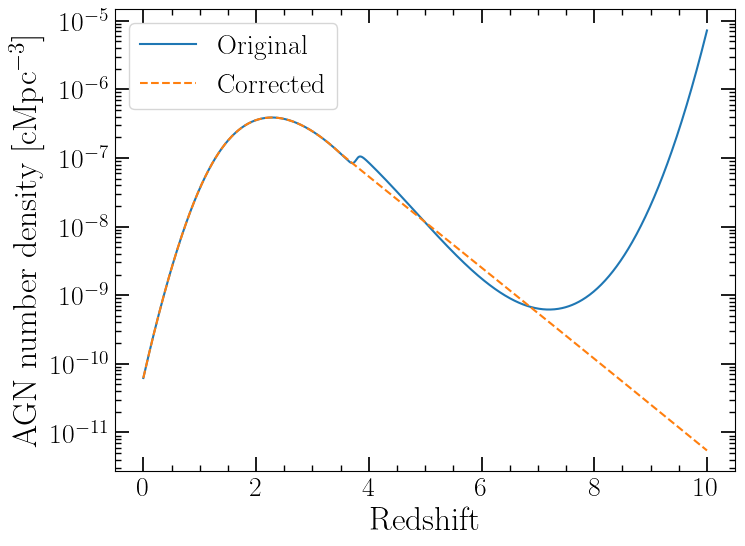

In [5]:
thresh = 46.5
AGN_ZPRIOR = f'{thresh}_kulkarni'
z_count_ax = np.linspace(0, 3, 1024+1)

# Load AGN distribution
filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
z, n = np.load(filename)
AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)

# Calculate old Kulkarni Nagn
n_of_z = get_n_of_z(qlf='kulkarni', log10_Lbol_thresh=thresh)
qlf_numdenses = n_of_z(REDSHIFT).flatten()
Nagn_total = romb(4 * np.pi * n_of_z(z_count_ax) * COSMO.differential_comoving_volume(z_count_ax), dx=np.diff(z_count_ax)[0])
print('Kulkarni:', int(Nagn_total))

# Calculate corrected Kulkarni Nagn
offset = qlf_numdenses[0] / pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT)(REDSHIFT)[0]
numdens_corrected_kulkarni = pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT, scaling=offset)
Nagn_total = romb(4 * np.pi * numdens_corrected_kulkarni(z_count_ax) * COSMO.differential_comoving_volume(z_count_ax), dx=np.diff(z_count_ax)[0])
print('Corrected Kulkarni:', int(Nagn_total))

# Plot old and new number densities
plt.figure(figsize=(8,6))
plt.plot(REDSHIFT, qlf_numdenses, label='Original')
plt.plot(REDSHIFT, numdens_corrected_kulkarni(REDSHIFT), linestyle='dashed', label='Corrected')
plt.semilogy()
plt.xlabel('Redshift')
plt.ylabel(r'AGN number density [$\mathrm{cMpc^{-3}}$]')
plt.legend()
# plt.savefig('./plots/corrected_kulkarni_46.5.pdf', bbox_inches='tight')
plt.show()


# Generate AGN redshift posteriors: $p_{\rm agn}(z | \hat{z}, \hat{L}_{\rm bol})$

In [6]:
AGN_ZPRIOR = None
AGN_ZPRIOR_FUNCTION = None
AGN_COMDIST_MAX = COSMO.comoving_distance(AGN_ZMAX).value


def get_agn_zprior() -> callable:
    """
    Function looks at the global string AGN_ZPRIOR and returns the appropriate function. 
    I don't know why I didn't give this string as an argument to this function.
    
    AGN_ZPRIOR can be:
    'positive_redshift', 'uniform_comoving_volume', '44.5_<QLF>', '45.0_<QLF>', '45.5_<QLF>', '46.0_<QLF>', '46.5_<QLF>'
    """

    if AGN_ZPRIOR == 'uniform_comoving_volume':
        return lambda z: uniform_comoving_prior(z)
    
    elif str(AGN_ZPRIOR)[:4] in LOG10_LBOL_THRESHES.astype(str):
        filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
        if VERBOSE:
            print(f'Loading AGN redshift distribution calculated from QLF from file: {filename}')
        z, n = np.load(filename)
        return interp1d(z, n, bounds_error=False, fill_value=0)
    
    elif AGN_ZPRIOR == 'positive_redshift':  # Equivalent to a uniform-in-redshift prior. Redundant since the Z_INTEGRAL_AX is >0, but this way we enforce a conscious decision on the prior.
        return lambda z: z_cut(-z, zcut=0)
    
    else:
        sys.exit(f'AGN redshift prior not recognized: {AGN_ZPRIOR}. \nExiting...')


def compute_and_save_lum_informed_posteriors_hdf5(filename, agn_z, agn_z_err, agn_Lbol, agn_ra, agn_dec, n_norm=100):
    '''
    Compute luminosity-informed AGN redshift posterior distributions and save them
    to an HDF5 file.

    For each AGN, the function combines a truncated-normal redshift likelihood with
    a luminosity-dependent redshift prior derived from the Kulkarni et al. quasar
    luminosity function (QLF). The resulting posterior is normalized and evaluated
    on the global ``Z_INTEGRAL_AX`` redshift grid.

    The individual posterior distributions, input redshifts, and sky
    coordinates are written to an HDF5 file.

    Parameters
    ----------
    filename : str or path-like
        Path to the output HDF5 file.
    agn_z : array-like
        Mean AGN redshifts.
    agn_z_err : array-like
        Redshift uncertainties corresponding to ``all_agn_z``.
    agn_Lbol : array-like
        Bolometric luminosities, used to construct the
        luminosity-informed redshift prior.
    agn_ra : array-like
        Right ascension values for the AGN.
    agn_dec : array-like
        Declination values for the AGN.
    n_norm : int, optional
        Number of points used to evaluate the numerical normalization of each
        posterior. Default is 100.

    Returns
    -------
    summed_posteriors : numpy.ndarray
        Sum of all normalized posterior distributions,
        evaluated on ``Z_INTEGRAL_AX``.

    Notes
    -----
    The luminosity-informed prior is constructed by converting each AGN's
    bolometric luminosity to an absolute magnitude and evaluating the QLF as a
    function of redshift. The unphysical peak in the Kulkarni QLF is removed 
    from the prior before normalization.

    The output HDF5 file contains the datasets:

    - ``agn_redshift_posteriors``: Posterior distributions with shape
      ``(n_agn, len(Z_INTEGRAL_AX))``.
    - ``redshift``: Input central redshift estimates.
    - ``ra`` and ``dec``: Sky coordinates.
    '''

    n_agn = len(agn_z)
    n_z = len(Z_INTEGRAL_AX)  # Only need to save the posterior evaluated at this axis
    
    # Precompute stuff for the prior
    agn_zprior_norm_ax = np.linspace(0, AGN_ZMAX, 1024+1)
    dV_dzdOmega_precompute = COSMO.comoving_volume(agn_zprior_norm_ax).value
    dz = np.diff(agn_zprior_norm_ax)[0]

    with h5py.File(filename, "w") as f:
        full_posterior_dset = f.create_dataset("agn_redshift_posteriors", shape=(n_agn, n_z), dtype=np.float32)
        z_dset = f.create_dataset("redshift", shape=n_agn, dtype=np.float32)
        ra_dset = f.create_dataset("ra", shape=n_agn, dtype=np.float32)
        dec_dset = f.create_dataset("dec", shape=n_agn, dtype=np.float32)

        z_dset[:] = agn_z
        ra_dset[:] = agn_ra
        dec_dset[:] = agn_dec     
        
        summed_posteriors = np.zeros_like(Z_INTEGRAL_AX)
        for i, (mu, sigma) in tqdm( enumerate(zip(agn_z, agn_z_err)), total=len(agn_z) ):
            mu, sigma = np.atleast_1d(mu), np.atleast_1d(sigma)

            t = np.linspace(0, 1, n_norm)
            z_norm_ax = np.maximum(mu - 10*sigma, ZMIN) + t * (20 * sigma)

            # Get luminosity-informed redshift prior from QLF
            n_of_z = lambda z: 10**log10_QLF_kulkarni(M=L2M(agn_Lbol[i]), z=z)
            prior_wpeak = numdens2pdf(n_of_z=n_of_z, redshift=agn_zprior_norm_ax, dV_dzdOmega_precompute=dV_dzdOmega_precompute)
            prior, _ = remove_peak(prior_wpeak, agn_zprior_norm_ax)
            prior_norm = romb(prior, dx=dz)

            pi_agn = interp1d(x=agn_zprior_norm_ax, y=prior / prior_norm, kind='linear', bounds_error=False, fill_value=0)
            pi_at_normax = pi_agn(z_norm_ax)
            pi_at_intax = pi_agn(Z_INTEGRAL_AX)

            # Get normalization of all posteriors --> evaluate on z_norm_ax
            posteriors_unnorm = truncnorm_pdf_inplace(z_norm_ax, mu, sigma, zmin=ZMIN)
            posteriors_unnorm *= z_cut(z_norm_ax, zcut=AGN_ZMAX)
            posteriors_unnorm *= pi_at_normax
            z_norm = np.trapezoid(posteriors_unnorm, z_norm_ax)

            # Get normalized posteriors --> evaluate on Z_INTEGRAL_AX
            posteriors = truncnorm_pdf_inplace(Z_INTEGRAL_AX, mu, sigma, zmin=ZMIN)
            posteriors *= z_cut(Z_INTEGRAL_AX, zcut=AGN_ZMAX)
            posteriors *= pi_at_intax
            posteriors /= z_norm

            if np.sum(np.isnan(posteriors)) != 0:
                print('Got nan :(')
                continue
                
            full_posterior_dset[i,:] = posteriors
            summed_posteriors += posteriors.flatten()
    
    return summed_posteriors


In [7]:
for qlf in ['kulkarni']:  # 'shenA', 'shenB', 
    for thresh in LOG10_LBOL_THRESHES[::-1]:

        df = pd.read_csv(QUAIA_PATH)
        cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "loglbol_corr"]
        data = df[cols]
        b              = data["b"].to_numpy()
        loglbol_corr   = data["loglbol_corr"].to_numpy()
        outside_galactic_plane = np.logical_or((b > 10), (b < -10))
        above_lbol_thresh = loglbol_corr >= float(thresh)

        agn_ra             = data["ra"].to_numpy()[outside_galactic_plane & above_lbol_thresh]
        agn_dec             = data["dec"].to_numpy()[outside_galactic_plane & above_lbol_thresh]
        agn_redshift       = data["redshift_quaia"].to_numpy()[outside_galactic_plane & above_lbol_thresh]
        agn_redshift_err   = data["redshift_quaia_err"].to_numpy()[outside_galactic_plane & above_lbol_thresh]

        filename = f'{AGN_DIST_DIR}/quaia_zleq{AGN_ZCUT}_{thresh}_{qlf}.hdf5'
        print(len(agn_redshift))
        AGN_ZPRIOR = f'{thresh}_{qlf}'
        AGN_ZPRIOR_FUNCTION = get_agn_zprior()

        # SoP_lum_informed = compute_and_save_posteriors_hdf5_lum_informed_prior(filename=filename, 
        #                                                                        all_agn_z=agn_redshift, 
        #                                                                        all_agn_z_err=agn_redshift_err, 
        #                                                                        all_agn_Lbol=loglbol_corr, 
        #                                                                        n_norm=128+1,
        #                                                                        ra=agn_ra, 
        #                                                                        dec=agn_dec)
        

198402
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy
1084513
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_45.5_kulkarni.npy
1243143
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_44.5_kulkarni.npy


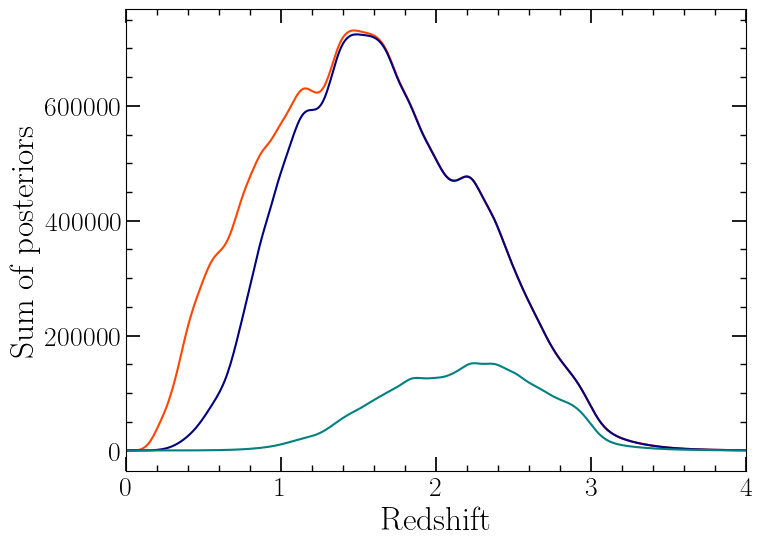

In [8]:
# Plot summed posteriors as verification

def get_label_linestyle(qlf):
    if qlf == 'shenA':
        linestyle = 'dotted'
        label = 'Shen+2020 A'
    elif qlf == 'shenB':
        linestyle = 'dashed'
        label = 'Shen+2020 B'
    elif qlf == 'kulkarni':
        linestyle = 'solid'
        label = 'Kulkarni+2019'
    else:
        sys.exit(f'Do not recognize QLF: {qlf}')
    return label, linestyle


def get_SoP(L_threshes, QLF):
    '''
    Get sums of posteriors for specified luminosity thresholds and QLF
    '''
    SoPs = []
    for L_thresh in L_threshes:
        filename = f'{AGN_DIST_DIR}/quaia_zleq{float(AGN_ZCUT)}_{L_thresh}_{QLF}.hdf5'
        with h5py.File(filename, "r") as f:
            agn_posterior_dset = f["agn_redshift_posteriors"][()]
        SoPs.append(np.sum(agn_posterior_dset, axis=0))
    return SoPs


fig1, ax1 = plt.subplots(figsize=(8,6))
for qlf in ['kulkarni']:  # 'shenA', 'shenB', 
    label, linestyle = get_label_linestyle(qlf)
    SoP44_5, SoP45_5, SoP46_5 = get_SoP(LOG10_LBOL_THRESHES, qlf)
    for i, SoP in enumerate([SoP44_5, SoP45_5, SoP46_5]):
        ax1.plot(Z_INTEGRAL_AX, SoP, color=COLORS[i], linestyle=linestyle)
ax1.set_xlim(0, 4)
ax1.set_xlabel('Redshift')
ax1.set_ylabel('Sum of posteriors')
plt.show()


# Plot results

In [9]:
def obs_numdens_of_z(z, sum_of_posteriors):
    observed_sky_fraction = 1 - np.sin(np.deg2rad(10))
    numdens = pdf2numdens(sum_of_posteriors, Z_INTEGRAL_AX, scaling=1 / observed_sky_fraction)
    return numdens(z)


In [10]:
# Stuff for plotting Veronesi+25 completeness bins
THRESHOLD_MAP = {"46.5": 0, "46.0": 1, "45.5": 2, "45.0": 3, "44.5": 4}
V25_zedges = np.array([0.0000, 0.1875, 0.3750, 0.5625, 0.7500, 0.9375, 1.1250, 1.3125, 1.5, AGN_ZMAX])
QUAIA_C_VALS = np.array([
                    [0.000, 0.000, 0.229, 0.945, 0.718],
                    [1.000, 1.000, 1.000, 1.000, 0.781],
                    [1.000, 1.000, 1.000, 1.000, 0.408],
                    [1.000, 0.891, 1.000, 0.681, 0.211],
                    [1.000, 1.000, 0.994, 0.429, 0.138],
                    [1.000, 1.000, 0.837, 0.258, 0.085],
                    [0.927, 0.940, 0.576, 0.179, 0.060],
                    [1.000, 1.000, 0.482, 0.155, 0.053],
                    [0., 0., 0., 0., 0.]])


def make_qlf_plots(axs, qlf, L_thresh, redshift, color):

    try:
        ax1, ax2, ax3 = axs
    except:
        ax1, ax3 = axs

    # Plot number densities
    n_of_z = get_n_of_z(qlf=qlf, log10_Lbol_thresh=L_thresh)
    qlf_numdenses = n_of_z(redshift).flatten()

    sum_of_posteriors = get_SoP(np.atleast_1d(L_thresh), qlf)[0]
    obs_numdenses = obs_numdens_of_z(redshift, sum_of_posteriors)

    AGN_ZPRIOR = f'{L_thresh}_{qlf}'
    filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
    z, n = np.load(filename)
    AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)
    
    offset = qlf_numdenses[0] / pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT)(redshift)[0]
    numdens_corrected_kulkarni = pdf2numdens(AGN_ZPRIOR_FUNCTION(REDSHIFT), REDSHIFT, scaling=offset)

    ax1.plot(redshift[1:], qlf_numdenses[1:], color=color, linewidth=1, linestyle='dotted')
    ax1.plot(redshift, numdens_corrected_kulkarni(redshift), color=color, linewidth=2, linestyle='dashed')
    ax1.plot(redshift[1:], obs_numdenses[1:], color=color, linewidth=3, linestyle='solid')

    # Plot PDFs
    agn_redshift_pdf = numdens2pdf(n_of_z, redshift, cosmo=COSMO) 
    if qlf == 'kulkarni':
        agn_redshift_pdf_wpeak = agn_redshift_pdf.copy()
        agn_redshift_pdf, _ = remove_peak(agn_redshift_pdf_wpeak, REDSHIFT)
    try:
        ax2.plot(redshift, agn_redshift_pdf, color=color, linewidth=3, linestyle=linestyle)
    except:
        print('Not plotting PDFs')

    # Plot completenesses
    fc_of_z = obs_numdenses / qlf_numdenses

    # np.save(f'{AGN_DIST_DIR}/completeness_zleq{float(AGN_ZCUT)}_{L_thresh}_{qlf}', np.array([redshift, fc_of_z]))

    fc_of_z[fc_of_z > 1] = 1
    ax3.plot(redshift[1:], fc_of_z[1:], color=color, linewidth=3, linestyle='solid', label=label)

    return


Not plotting PDFs
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_44.5_kulkarni.npy
Not plotting PDFs
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_45.5_kulkarni.npy
Not plotting PDFs
Loading AGN redshift distribution calculated from QLF from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_46.5_kulkarni.npy


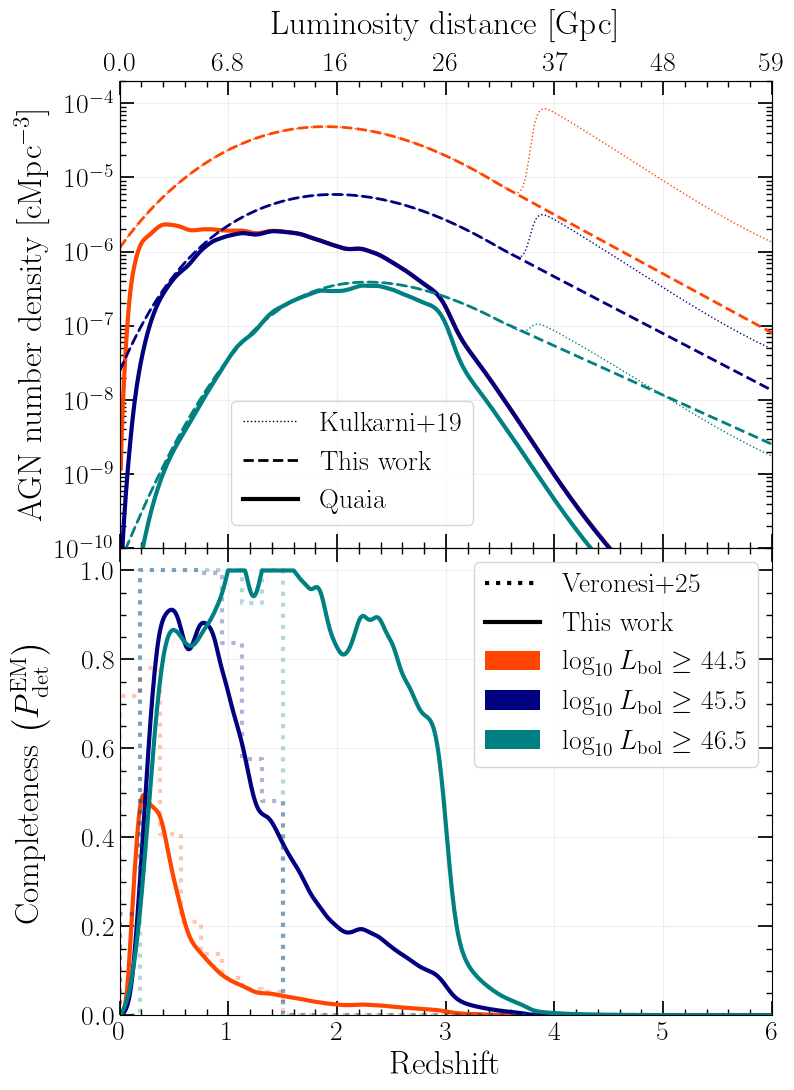

In [11]:
# The number densities and completeness functions

fig, ax = plt.subplots(2, 1, figsize=(8, 11))
ax1, ax3 = ax[0], ax[1]

for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):
    ax3.step(V25_zedges, np.append( 0, np.array(QUAIA_C_VALS[:, THRESHOLD_MAP[str(L_thresh)]]) ), linewidth=3, label='Veronesi+25', color=COLORS[i], linestyle='dotted', alpha=0.3)
    make_qlf_plots([ax1, ax3], 'kulkarni', L_thresh, REDSHIFT, color=COLORS[i])
    AGN_ZPRIOR = f'{L_thresh}_kulkarni'
    AGN_ZPRIOR_FUNCTION = get_agn_zprior()

# Top axis
upperax1 = ax1.twiny()
upperticks = np.array([0, 1, 2, 3, 4, 5, 6])
upperax1.set_xticks(upperticks)
upperax1.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax1.set_xlabel('Luminosity distance [Gpc]', labelpad=12, fontsize=24)
ax1.set_xlim(0, 6)
upperax1.set_xlim(0, 6)
ax1.set_xticklabels([])
ax3.set_xlim(0, 6)

ax1.semilogy()
ax1.set_ylim(1e-10, 2e-4)
ax1.set_ylabel(r'AGN number density $[\mathrm{cMpc^{-3}}]$')
ax1.grid(alpha=0.2)
ax3.grid(alpha=0.2)
ax3.set_ylim(0, 1.05)
ax3.set_ylabel(r'Completeness $\left(P_{\rm det}^{\rm EM}\right)$')
ax3.set_xlabel('Redshift')
custom_handles = [Line2D([], [], color='black', linestyle='dotted', label='Kulkarni+19', linewidth=1),
                  Line2D([], [], color='black', linestyle='dashed', label='This work', linewidth=2),
                  Line2D([], [], color='black', linestyle='solid', label='Quaia', linewidth=3)]
ax1.legend(
    handles=custom_handles,
    loc='lower left',
    bbox_to_anchor=(0.15, 0.02)
)
custom_handles = [Line2D([], [], color='black', linestyle='dotted', linewidth=3, label='Veronesi+25'),
                  Line2D([], [], color='black', linestyle='solid', linewidth=3, label='This work')]
color_handles = [
    Patch(facecolor=COLORS[0], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 44.5$'),

    Patch(facecolor=COLORS[1], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 45.5$'),

    Patch(facecolor=COLORS[2], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 46.5$'),
]
handles = custom_handles + color_handles
ax3.legend(handles=handles)

plt.tight_layout()
fig.subplots_adjust(hspace=0)
fig.align_ylabels(ax)
# plt.savefig(f'{PLOT_DIR}/completeness.pdf', bbox_inches='tight')
plt.show()


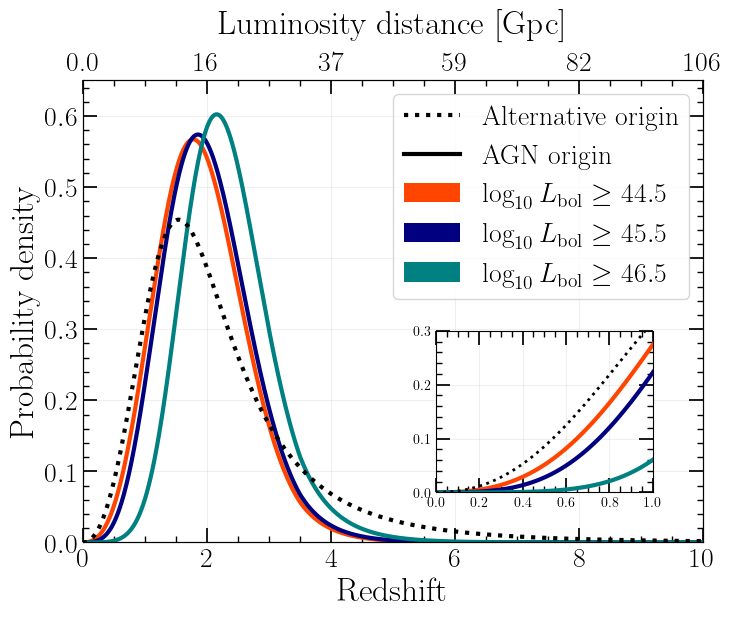

In [12]:
# GW redshift population models

def make_gw_zpop_plots(ax, qlf, L_thresh, redshift, color, label, linestyle):
    AGN_ZPRIOR = f'{L_thresh}_{qlf}'
    filename = f'{AGN_DIST_DIR}/agn_redshift_pdf_{AGN_ZPRIOR}.npy'
    z, n = np.load(filename)
    AGN_ZPRIOR_FUNCTION = interp1d(z, n, bounds_error=False, fill_value=0)
    agn_redshift_pdf = AGN_ZPRIOR_FUNCTION(redshift)
    observed_rate_evolution = agn_redshift_pdf * time_dilation_correction(redshift) / romb(agn_redshift_pdf * time_dilation_correction(redshift), dx=np.diff(redshift)[0])
    ax.plot(redshift, observed_rate_evolution, color=color, linewidth=3, linestyle=linestyle, label=label)
    return


### PLOT ###
fig, ax = plt.subplots(figsize=(8,6))
alt_pop = uniform_comoving_prior(REDSHIFT) * time_dilation_correction(REDSHIFT) * merger_rate_madau_dickinson(REDSHIFT, b=3.3, c=2.55, d=6.1)
alt_pop_norm = alt_pop / romb(alt_pop, dx=np.diff(REDSHIFT)[0])
ax.plot(REDSHIFT, alt_pop_norm, color='black', linestyle='dotted', linewidth=3, zorder=3)
for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):  
    make_gw_zpop_plots(ax, 'kulkarni', L_thresh, REDSHIFT, color=COLORS[i], linestyle='solid', label = r'$\log_{10} L_{\rm bol} \geq$ ' + str(L_thresh))
ax.set_xlim(ZMIN, ZMAX)
ax.set_xlabel('Redshift')
ax.set_ylabel('Probability density')
handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([], [], color='black', linestyle='dotted', linewidth=3, label='Alternative origin'),
    Line2D([], [], color='black', linestyle='solid', linewidth=3, label='AGN origin'),
]
color_handles = [
    # Color categories
    Patch(facecolor=COLORS[0], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 44.5$'),

    Patch(facecolor=COLORS[1], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 45.5$'),

    Patch(facecolor=COLORS[2], edgecolor='none',
          label=r'$\log_{10} L_{\rm bol} \geq 46.5$'),
]
handles = custom_handles + color_handles
ax.legend(handles=handles)
ax.set_ylim(0, 0.65)

# Top axis
upperax = ax.twiny()
upperticks = np.array([0, 2, 4, 6, 8, 10])
upperax.set_xticks(upperticks)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)

ax.set_xlim(0, ZMAX)
upperax.set_xlim(0, ZMAX)

ax.grid(alpha=0.2)

# --------------------------------------------------
# Inset
# --------------------------------------------------

axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc="lower right",
    borderpad=1.8
)

# Plot the same curves in the inset
axins.plot(
    REDSHIFT,
    alt_pop_norm,
    color='black',
    linestyle='dotted',
    linewidth=2.0,
    zorder=3
)

for i, L_thresh in enumerate(LOG10_LBOL_THRESHES):
    make_gw_zpop_plots(
        axins,
        'kulkarni',
        L_thresh,
        REDSHIFT,
        color=COLORS[i],
        linestyle='solid',
        label=''
    )

# Zoom range
axins.set_xlim(0, 1.0)
axins.set_ylim(0, 0.3)

# Inset appearance
axins.tick_params(axis='both', labelsize=10)
axins.grid(alpha=0.2)

# plt.savefig(f'{PLOT_DIR}/all_populations.pdf', bbox_inches='tight')
plt.show()
